# Speaker Classification Accuracy of the Cloned Audio

The assignment asks for *speaker classification accuracy to assess the performance of the generated audio's target speaker*: does a clone sound like the speaker it was cloned from?

**Method** (closed-set speaker identification over the 300 cloned TIMIT speakers):
1. **Enrollment:** for each speaker, the average embedding of 9 of their real TIMIT recordings
2. **Test:** each speaker's clone (from `clone_speakers.py`) is assigned to the enrolled speaker with the highest cosine similarity; it's correct if that is the speaker it was cloned from
3. **Ceiling:** the same test on each speaker's 10th, held-out real recording shows how well the judge identifies genuine speech

**Judges:**
- **ECAPA-TDNN** (SpeechBrain, trained on VoxCeleb): independent of the cloning system, so this is the headline metric
- **SV2TTS encoder**: the speaker encoder that conditioned the cloning. Shown for comparison only, since it grades its own output

All audio is resampled to 16 kHz and leading/trailing silence is trimmed. Chance level is 1/300 = 0.33%.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import torch
import matplotlib.pyplot as plt
import functions

import warnings
warnings.filterwarnings("ignore")

from speechbrain.inference.speaker import EncoderClassifier

#### Data
The held-out real recording is each speaker's longest SX/SI sentence (the same one used in the fair detection test); the other 9 are used for enrollment.

In [2]:
speaker_dirs = {p.name: p for split in ['TIMIT_orig/TRAIN', 'TIMIT_orig/TEST'] for p in Path(split).glob('*/*')}
speakers = sorted(p.stem for p in Path('data/cloned_audio').glob('*.wav'))

rows = []
for spk in speakers:
    recordings = sorted(speaker_dirs[spk].glob('*.WAV.wav'))
    held_out = max((r for r in recordings if r.name[:2] in ('SX', 'SI')), key=lambda f: sf.info(f).duration)
    rows.append({'speaker': spk, 'gender': spk[0], 'clone': f'data/cloned_audio/{spk}.wav', 'held_out': str(held_out),
                 'enroll': [str(r) for r in recordings if r != held_out]})

data = pd.DataFrame(rows)
print(len(data), 'speakers,', data.gender.value_counts().to_dict())
print('Enrollment recordings per speaker:', data.enroll.map(len).unique())

300 speakers, {'F': 192, 'M': 108}
Enrollment recordings per speaker: [9]


In [3]:
def load(path):
    audio, _ = librosa.load(path, sr=16000)
    return librosa.effects.trim(audio, top_db=30)[0]


ecapa = EncoderClassifier.from_hparams(source='speechbrain/spkrec-ecapa-voxceleb', savedir='.cache/ecapa', run_opts={'device': 'cpu'})

def ecapa_embed(audio):
    with torch.no_grad():
        emb = ecapa.encode_batch(torch.tensor(audio, dtype=torch.float32)[None]).squeeze().numpy()
    return emb / np.linalg.norm(emb)


functions._load_voice_cloning()

def sv2tts_embed(audio):
    return functions.encoder.embed_utterance(functions.encoder.preprocess_wav(audio, 16000))


judges = {'ECAPA (independent)': ecapa_embed, 'SV2TTS encoder (self-grading)': sv2tts_embed}

Loaded encoder "encoder.pt" trained to step 1564501
Synthesizer using device: cpu
Building Wave-RNN
Trainable Parameters: 4.481M
Loading model weights at /Users/sammid.c/Documents/MLProjects26/VoiceCloned4/Voice-Cloning-and-Fake-Audio-Detection/WebApp/saved_models/default/vocoder.pt


#### Embeddings

In [4]:
# Embeds one file at a time with both judges (keeping all decoded audio in memory swaps heavily on an 8 GB machine).
# Embeddings are cached in .cache/speaker_embeddings.npz so an interrupted run resumes where it stopped.
cache_file = Path('.cache/speaker_embeddings.npz')
cache = dict(np.load(cache_file, allow_pickle=True)['emb'].item()) if cache_file.exists() else {}

paths = sorted(set(data.clone) | set(data.held_out) | {p for ps in data.enroll for p in ps})
todo = [p for p in paths if p not in cache]
print(f'{len(paths)} files, {len(paths) - len(todo)} cached')

for n, path in enumerate(todo, 1):
    audio = load(path)
    cache[path] = {name: embed(audio) for name, embed in judges.items()}
    if n % 100 == 0 or n == len(todo):
        np.savez(cache_file, emb=np.array(cache, dtype=object))
        print(f'{len(paths) - len(todo) + n}/{len(paths)} embedded', flush=True)

embeddings = {}
for name in judges:
    centroids = np.stack([np.mean([cache[p][name] for p in ps], axis=0) for ps in data.enroll])
    centroids /= np.linalg.norm(centroids, axis=1, keepdims=True)
    embeddings[name] = {'centroids': centroids,
                        'clone': np.stack([cache[p][name] for p in data.clone]),
                        'real (held out)': np.stack([cache[p][name] for p in data.held_out])}

3300 files, 0 cached


100/3300 embedded


200/3300 embedded


300/3300 embedded


400/3300 embedded


...

2900/3300 embedded


3000/3300 embedded


3100/3300 embedded


3200/3300 embedded


3300/3300 embedded


#### Speaker identification accuracy

In [5]:
genders = data.gender.values
results, similarities = [], {}

for judge, e in embeddings.items():
    for test_set in ['clone', 'real (held out)']:
        sims = e[test_set] @ e['centroids'].T          # (300 test files, 300 enrolled speakers)
        ranking = np.argsort(-sims, axis=1)
        target = np.arange(len(data))
        rank_of_target = (ranking == target[:, None]).argmax(axis=1)
        target_sim = sims[target, target]
        impostor_sim = sims[~np.eye(len(data), dtype=bool)]
        similarities[(judge, test_set)] = (target_sim, impostor_sim)
        results.append({'judge': judge, 'test audio': test_set,
                        'top-1 accuracy': (rank_of_target == 0).mean(),
                        'top-5 accuracy': (rank_of_target < 5).mean(),
                        'gender accuracy': (genders[ranking[:, 0]] == genders).mean(),
                        'median rank': np.median(rank_of_target) + 1,
                        'mean target sim': target_sim.mean(),
                        'mean impostor sim': impostor_sim.mean()})

results = pd.DataFrame(results)
print(f'Chance top-1 accuracy: {1/len(data):.4f}')
results.style.format({c: '{:.3f}' for c in results.columns if 'accuracy' in c or 'sim' in c}).hide(axis='index')

Chance top-1 accuracy: 0.0033


judge,test audio,top-1 accuracy,top-5 accuracy,gender accuracy,median rank,mean target sim,mean impostor sim
ECAPA (independent),clone,0.307,0.627,0.993,3.000000,0.353,0.113
ECAPA (independent),real (held out),1.000,1.000,1.000,1.000000,0.847,0.159
SV2TTS encoder (self-grading),clone,0.510,0.793,0.997,1.000000,0.819,0.650
SV2TTS encoder (self-grading),real (held out),0.987,1.000,1.000,1.000000,0.934,0.677


Distribution of cosine similarity between each test file and its true speaker (target) vs all other speakers (impostors).

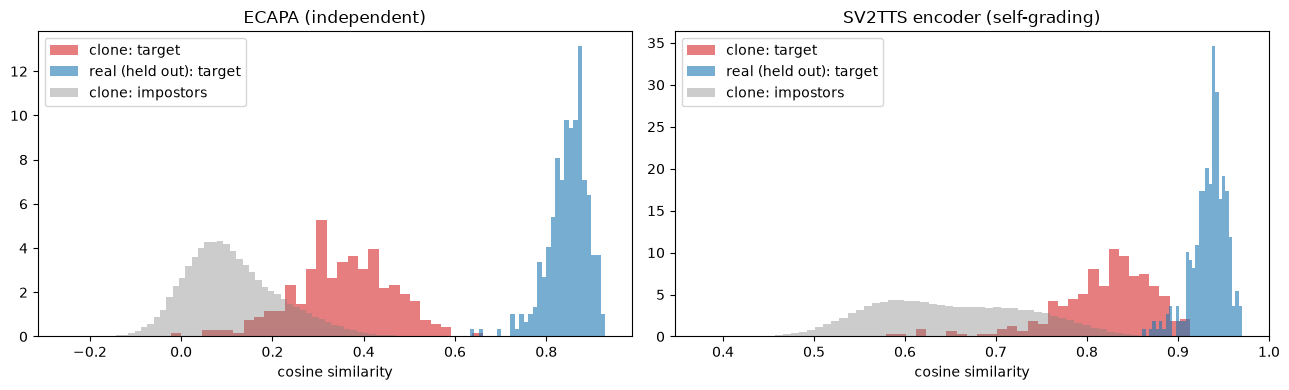

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
for ax, judge in zip(axes, judges):
    for test_set, color in [('clone', 'tab:red'), ('real (held out)', 'tab:blue')]:
        target_sim, impostor_sim = similarities[(judge, test_set)]
        ax.hist(target_sim, bins=30, alpha=0.6, density=True, color=color, label=f'{test_set}: target')
    ax.hist(similarities[(judge, 'clone')][1], bins=60, alpha=0.4, density=True, color='gray', label='clone: impostors')
    ax.set_title(judge)
    ax.set_xlabel('cosine similarity')
    ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Which speakers were misidentified by the independent judge, and who were they mistaken for?
e = embeddings['ECAPA (independent)']
pred = (e['clone'] @ e['centroids'].T).argmax(axis=1)
wrong = data.assign(predicted=data.speaker.values[pred])[pred != np.arange(len(data))]
print(f'{len(wrong)} of {len(data)} clones misidentified; {(wrong.speaker.str[0] != wrong.predicted.str[0]).sum()} of those as the other gender')
wrong[['speaker', 'predicted']].head(15)

208 of 300 clones misidentified; 2 of those as the other gender


,speaker,predicted
0,FADG0,FMAF0
2,FAJW0,FJEN0
3,FAKS0,FPKT0
5,FALR0,FKLH0
6,FAPB0,FJEM0
7,FASW0,FCMR0
8,FAWF0,FAPB0
10,FBCG1,FJXM0
11,FBCH0,FJLM0
12,FBJL0,FJEN0
